In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%cd -q ..
from crest.model.HierarchalTensorGraph import HierarchalTensorGraph
import tensorflow as tf

/Users/draghun1/miniconda3/envs/crest_cpu/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
/Users/draghun1/miniconda3/envs/crest_cpu/lib/python3.10/site-packages/tensorflow/python/keras/engine/training_arrays_v1.py:37: UserWarning: A NumPy version >=1.22.4 and <1.29.0 is required for this version of SciPy (detected version 1.22.3)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


In [3]:
import numpy as np
import crest.model.TensorSpec as ts

class Add1(HierarchalTensorGraph):
    def __init__(self, name):
        self.name = name

        def add(X):
            s_1 = X['s_1'] if X['s_1'] is not None else 0
            s_2 = X['s_2'] if X['s_2'] is not None else 0

            v = s_1 + s_2 + X['x_1']

            return {'s_1':  v}

        # call the basenode constructor
        super().__init__(add,
                         name=name,
                         inputs={'x_1': np.ones((1, 3)), 's_2': np.ones((1)), 's_1': np.ones((1))},
                         outputs={'s_1': None}
                         )


class Add2(HierarchalTensorGraph):
    def __init__(self, name):
        self.name = name

        def add(X):
            s_1 = X['s_1'] if X['s_1'] is not None else 0
            s_2 = X['s_2'] if X['s_2'] is not None else 0

            v = s_1 + s_2 + X['x_2']

            return {'s_2':  v}

        # call the basenode constructor
        super().__init__(add,
                         name=name,
                         inputs={'x_2': np.ones((1, 3)), 's_2': np.ones((1)), 's_1': np.ones((1))},
                         outputs={'s_2': None}
                         )

In [4]:
htg = HierarchalTensorGraph(name='parent')
add_1 = Add1('add_1')
add_2 = Add2('add_2')

htg.add_edge('input', add_1, rollout_axis=1)
htg.add_edge('input', add_2, rollout_axis=1)
htg.add_edge(add_1, add_2, rollout_axis=1)
htg.add_edge(add_2, add_1, rollout_axis=1)
htg.add_edge(add_1, add_1, rollout_axis=1)
htg.add_edge(add_2, add_2, rollout_axis=1)
htg.add_edge(add_1, 'output')
htg.add_edge(add_2, 'output')

In [5]:
htg.print_edge_labels()

input add_1 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1'])}
input add_2 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1']), ('input', 'add_2'): ([], ['x_2', 's_2', 's_1'])}
add_1 add_2 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1']), ('input', 'add_2'): ([], ['x_2', 's_2', 's_1']), ('add_1', 'add_2'): (['s_1'], ['x_2', 's_2', 's_1'])}
add_1 add_1 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1']), ('input', 'add_2'): ([], ['x_2', 's_2', 's_1', 's_1', 'x_2', 's_2', 's_1']), ('add_1', 'add_2'): (['s_1'], ['x_2', 's_2', 's_1']), ('add_1', 'add_1'): (['s_1'], ['x_1', 's_2', 's_1'])}
add_1 output {('input', 'add_1'): ([], ['x_1', 's_2', 's_1', 's_1', 'x_1', 's_2', 's_1']), ('input', 'add_2'): ([], ['x_2', 's_2', 's_1', 's_1', 'x_2', 's_2', 's_1']), ('add_1', 'add_2'): (['s_1'], ['x_2', 's_2', 's_1']), ('add_1', 'add_1'): (['s_1'], ['x_1', 's_2', 's_1']), ('add_1', 'output'): (['s_1'], [])}
add_2 add_1 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1', 's_1', 'x_1', 's_2', 's_1']), ('input', 'ad

,source,target,source output,target inputs,valid
0,input,add_1,[],"['s_2', 's_1', 'x_1']",True
1,input,add_2,[],"['s_2', 'x_2', 's_1']",True
2,add_1,add_2,['s_1'],"['s_2', 'x_2', 's_1']",True
3,add_1,add_1,['s_1'],"['s_2', 's_1', 'x_1']",True
4,add_1,output,"['s_2', 's_1']",[],True
5,add_2,add_1,['s_2'],"['s_2', 's_1', 'x_1']",True
6,add_2,add_2,['s_2'],"['s_2', 'x_2', 's_1']",True
7,add_2,output,['s_2'],[],True


input add_1 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1'])}
input add_2 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1']), ('input', 'add_2'): ([], ['x_2', 's_2', 's_1'])}
add_1 add_2 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1']), ('input', 'add_2'): ([], ['x_2', 's_2', 's_1']), ('add_1', 'add_2'): (['s_1'], ['x_2', 's_2', 's_1'])}
add_1 add_1 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1']), ('input', 'add_2'): ([], ['x_2', 's_2', 's_1', 's_1', 'x_2', 's_2', 's_1']), ('add_1', 'add_2'): (['s_1'], ['x_2', 's_2', 's_1']), ('add_1', 'add_1'): (['s_1'], ['x_1', 's_2', 's_1'])}
add_1 output {('input', 'add_1'): ([], ['x_1', 's_2', 's_1', 's_1', 'x_1', 's_2', 's_1']), ('input', 'add_2'): ([], ['x_2', 's_2', 's_1', 's_1', 'x_2', 's_2', 's_1']), ('add_1', 'add_2'): (['s_1'], ['x_2', 's_2', 's_1']), ('add_1', 'add_1'): (['s_1'], ['x_1', 's_2', 's_1']), ('add_1', 'output'): (['s_1'], [])}
add_2 add_1 {('input', 'add_1'): ([], ['x_1', 's_2', 's_1', 's_1', 'x_1', 's_2', 's_1']), ('input', 'ad

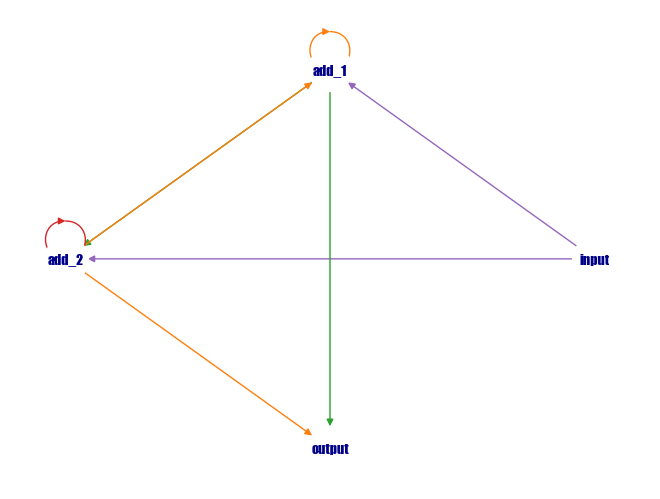

In [6]:
htg.draw()

In [7]:
htg({'x_1' : np.array([[1, 2, 3]]), 'x_2' : np.array([[1, 2, 3]])})

X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]])}
self.name='parent' self.inputs={}
init: self.name='input' self.X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]])}
init: self.name='add_2' self.X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]])}
init: self.name='add_1' self.X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]])}
_X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]])} X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]])}
name='output'
name='add_1'
Recurrence: get_item values values={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]])} self.name='input'
list(rollout_values.values())=[{'x_1': array([1]), 'x_2': array([1])}, {'s_2': None}, {'s_1': None}]
Recurrence: get_item values values={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]])} self.name='input'
Recurrence: get_item values values={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]])} self.name='input'
Recurrence: get_item self.name='add_2' index=1
X={'input': {'x_1': array([1]), 'x_2'

{'add_1': {'s_1': [array([1]), array([4]), array([11])]},
 'add_2': {'s_2': [array([1]), array([4]), array([11])]}}

In [8]:
class Add1(HierarchalTensorGraph):
    def __init__(self, name):
        self.name = name

        def add(X):
            s_1 = X['s_1'] if X['s_1'] is not None else 0
            
            v = s_1 + X['x_1']

            return {'s_1':  v}

        # call the basenode constructor
        super().__init__(add,
                         name=name,
                         inputs={'x_1': np.ones((1, 3)), 's_1': np.ones((1))},
                         outputs={'s_1': None}
                         )

htg_single = HierarchalTensorGraph(name='parent')
add_single = Add1('add_1')

htg_single.add_edge('input', add_single, rollout_axis=1)
htg_single.add_edge(add_single, add_single, rollout_axis=1)
htg_single.add_edge(add_single, 'output')

input add_1 {('input', 'add_1'): ([], ['x_1', 's_1'])}
add_1 add_1 {('input', 'add_1'): ([], ['x_1', 's_1']), ('add_1', 'add_1'): (['s_1'], ['x_1', 's_1'])}
add_1 output {('input', 'add_1'): ([], ['x_1', 's_1', 's_1', 'x_1', 's_1']), ('add_1', 'add_1'): (['s_1'], ['x_1', 's_1']), ('add_1', 'output'): (['s_1'], [])}
avial={'add_1': ['x_1', 's_1', 's_1', 'x_1', 's_1'], 'output': ['s_1']}
req={'add_1': ['x_1', 's_1', 's_1', 'x_1', 's_1'], 'output': []}
['s_1', 'x_1'] ['s_1', 'x_1']
['s_1'] []


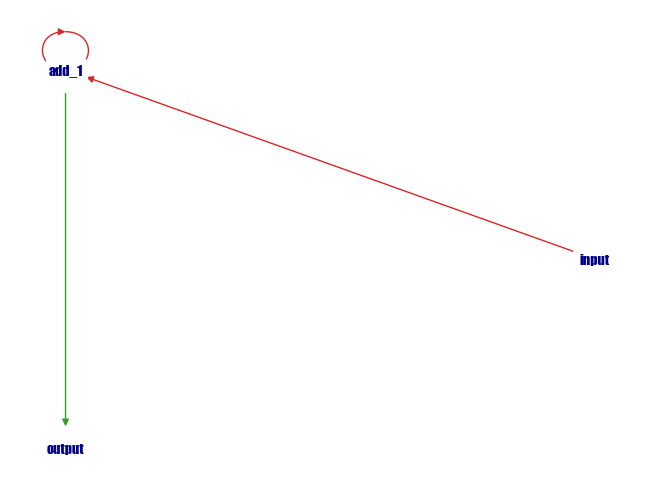

In [9]:
htg_single.draw()

In [10]:
htg_single({'x_1' : np.array([[1, 2, 3]])})

X={'x_1': array([[1, 2, 3]])}
self.name='parent' self.inputs={}
init: self.name='input' self.X={'x_1': array([[1, 2, 3]])}
init: self.name='add_1' self.X={'x_1': array([[1, 2, 3]])}
_X={'x_1': array([[1, 2, 3]])} X={'x_1': array([[1, 2, 3]])}
name='output'
name='add_1'
Recurrence: get_item values values={'x_1': array([[1, 2, 3]])} self.name='input'
list(rollout_values.values())=[{'x_1': array([1])}, {'s_1': None}]
Recurrence: get_item values values={'x_1': array([[1, 2, 3]])} self.name='input'
Recurrence: get_item values values={'x_1': array([[1, 2, 3]])} self.name='input'
X={'input': {'x_1': array([1])}, 'add_1': {'s_1': None}}
self.name='add_1' self.inputs={'x_1': array([[1., 1., 1.]]), 's_1': array([1.])}
self.name='add_1' self.inputs={'x_1': array([[1., 1., 1.]]), 's_1': array([1.])}
Recurrence: get_item self.name='add_1' index=1 self.cache[index]={'s_1': array([1])}
list(rollout_values.values())=[{'x_1': array([2])}, {'s_1': array([1])}]
Recurrence: get_item values values={'x_1': 

{'add_1': {'s_1': [array([1]), array([3]), array([6])]}}

In [11]:
import numpy as np
import crest.model.TensorSpec as ts

class Add1(HierarchalTensorGraph):
    def __init__(self, name):
        self.name = name

        def add(X):
            s_1 = X['s_1'] if X['s_1'] is not None else 0
            s_2 = X['s_2'] if X['s_2'] is not None else 0
            s_3 = X['s_3'] if X['s_3'] is not None else 0
            v = s_1 + s_2 + s_3 + X['x_1']

            return {'s_1':  v}

        # call the basenode constructor
        super().__init__(add,
                         name=name,
                         inputs={'x_1': np.ones((1, 3)), 's_3': np.ones((1)), 's_2': np.ones((1)), 's_1': np.ones((1))},
                         outputs={'s_1': None}
                         )


class Add2(HierarchalTensorGraph):
    def __init__(self, name):
        self.name = name

        def add(X):
            s_1 = X['s_1'] if X['s_1'] is not None else 0
            s_2 = X['s_2'] if X['s_2'] is not None else 0
            s_3 = X['s_3'] if X['s_3'] is not None else 0

            v = s_1 + s_2 + s_3 + X['x_2']

            return {'s_2':  v}

        # call the basenode constructor
        super().__init__(add,
                         name=name,
                         inputs={'x_2': np.ones((1, 3)), 's_3': np.ones((1)), 's_2': np.ones((1)), 's_1': np.ones((1))},
                         outputs={'s_2': None}
                         )
        
class Add3(HierarchalTensorGraph):
    def __init__(self, name):
        self.name = name

        def add(X):
            s_1 = X['s_1'] if X['s_1'] is not None else 0
            s_2 = X['s_2'] if X['s_2'] is not None else 0
            s_3 = X['s_3'] if X['s_3'] is not None else 0

            v = s_1 + s_2 + s_3 + X['x_3']

            return {'s_3':  v}

        # call the basenode constructor
        super().__init__(add,
                         name=name,
                         inputs={'x_3': np.ones((1, 3)), 's_3': np.ones((1)), 's_2': np.ones((1)), 's_1': np.ones((1))},
                         outputs={'s_3': None}
                         )

In [12]:
htg = HierarchalTensorGraph(name='parent')
add_1 = Add1('add_1')
add_2 = Add2('add_2')
add_3 = Add3('add_3')

htg.add_edge('input', add_1, rollout_axis=1)
htg.add_edge('input', add_2, rollout_axis=1)
htg.add_edge('input', add_3, rollout_axis=1)
htg.add_edge(add_1, add_2, rollout_axis=1)
htg.add_edge(add_2, add_1, rollout_axis=1)
htg.add_edge(add_2, add_3, rollout_axis=1)
htg.add_edge(add_3, add_2, rollout_axis=1)
htg.add_edge(add_3, add_1, rollout_axis=1)
htg.add_edge(add_1, add_3, rollout_axis=1)
htg.add_edge(add_1, add_1, rollout_axis=1)
htg.add_edge(add_2, add_2, rollout_axis=1)
htg.add_edge(add_3, add_3, rollout_axis=1)
htg.add_edge(add_1, 'output')
htg.add_edge(add_2, 'output')
htg.add_edge(add_3, 'output')

In [13]:
# default for a roll-out axis should be 1
# should be able to define the roll-out axis for each base node
htg({'x_1' : np.array([[1, 2, 3]]), 'x_2' : np.array([[1, 2, 3]]), 'x_3' : np.array([[1, 2, 3]])})

X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]]), 'x_3': array([[1, 2, 3]])}
self.name='parent' self.inputs={}
init: self.name='input' self.X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]]), 'x_3': array([[1, 2, 3]])}
init: self.name='add_2' self.X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]]), 'x_3': array([[1, 2, 3]])}
init: self.name='add_3' self.X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]]), 'x_3': array([[1, 2, 3]])}
init: self.name='add_1' self.X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]]), 'x_3': array([[1, 2, 3]])}
_X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]]), 'x_3': array([[1, 2, 3]])} X={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]]), 'x_3': array([[1, 2, 3]])}
name='output'
name='add_1'
Recurrence: get_item values values={'x_1': array([[1, 2, 3]]), 'x_2': array([[1, 2, 3]]), 'x_3': array([[1, 2, 3]])} self.name='input'
list(rollout_values.values())=[{'x_1': array([1]), 'x_2': array([1]), 'x_3': array([1])}, {'s_2': N

{'add_1': {'s_1': [array([1]), array([5]), array([18])]},
 'add_2': {'s_2': [array([1]), array([5]), array([18])]},
 'add_3': {'s_3': [array([1]), array([5]), array([18])]}}